# Linear Regression using Gradient Descent — Student Performance Dataset

**Dataset:** UCI Student Performance Dataset ( https://archive.ics.uci.edu/dataset/320/student+performance )

## IMPORT LIBRARIES AND LOAD DATASET

In [1]:
pip install ucimlrepo -q


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from ucimlrepo import fetch_ucirepo

- X_raw = student_performance.data.features: Extracts the feature columns (school, sex, age, study time, failures, absences, previous grades, etc.) as a pandas DataFrame.
- y_raw = student_performance.data.targets: Extracts the target column(s). The dataset provides G1, G2 (period grades) and G3 (final grade). We will predict the **final grade G3**.

In [3]:
student_performance = fetch_ucirepo(id=320)
X_raw = student_performance.data.features
y_raw = student_performance.data.targets
df = pd.concat([X_raw, y_raw], axis=1)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

## HANDLE MISSING VALUES

In [5]:
print("Missing values per column:\n")
print(df.isnull().sum())
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.int64]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:", df.isnull().sum().sum())

Missing values per column:

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Missing values after handling: 0


## SELECTING INPUT FEATURES AND TARGET VARIABLES

- **Target variable**: G3 — the student's final grade.
- **Input features**: All remaining columns, including:
  - Numeric features such as age, studytime, failures, absences, G1, G2.
  - Categorical features such as school, sex, address, famsize, etc. and several yes/no columns.

In [6]:
y = df['G3']

X = df.drop(columns=['G3'])

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


/var/folders/w9/twg87mcn7vbc5tmdkg__pv7w0000gn/T/ipykernel_5128/1889243536.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


## ENCODE CATEGORICAL VARIABLES

In [7]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (649, 41)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


## TRAIN-TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (519, 41)
X_test shape: (130, 41)


## FEATURE SCALING

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.to_numpy().astype(float)
y_test = y_test.to_numpy().astype(float)

print(X_train_scaled[:3])

[[ 0.98793212 -0.43741772 -0.25633653 -0.7543101   1.35296158 -0.38213263
   0.06813614 -0.18668    -0.19627032 -0.53967404 -0.21994878 -1.06834489
  -0.78961576  2.52554857  2.27289557 -0.73799923 -0.87481777  0.67061216
  -0.61967734  0.35813527 -0.26476989 -0.83099564 -0.50961627 -0.33369003
  -0.16028631 -1.16580054 -0.63757671 -0.2103939  -0.55138018  2.9045419
  -0.53054828  0.63458861 -0.26476989 -0.33724458  0.78217724 -0.26057865
  -0.97902531  0.50060205  0.35125009  0.56919205 -0.75993921]
 [-0.62953403  1.35013974  1.59142265 -0.7543101   0.12105446 -0.38213263
   0.06813614  0.75396969  1.50146793  3.57930872  2.07844218  1.01613255
   0.06593869  0.28109702 -0.15933701 -0.73799923  1.14309521  0.67061216
  -0.61967734  0.35813527 -0.26476989 -0.83099564 -0.50961627  2.99679316
  -0.16028631 -1.16580054 -0.63757671  4.75298949  1.81363067 -0.34428837
  -0.53054828  0.63458861 -0.26476989 -0.33724458  0.78217724  3.83761289
   1.02142405  0.50060205  0.35125009  0.56919205 

## ADD BIAS TERM AND PREPARE MATRICES

- np.c_[np.ones((m, 1)), X_train_scaled]: Adds a column of 1s to the feature matrix. This lets us represent the intercept (theta[0]) as just another weight, so predictions become a single matrix multiplication X.dot(theta).
- theta is initialized as a zero vector - Gradient Descent will iteratively update it.

In [10]:
m_train = X_train_scaled.shape[0]
m_test = X_test_scaled.shape[0]

X_train_bias = np.c_[np.ones((m_train, 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((m_test, 1)), X_test_scaled]

y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

n_features = X_train_bias.shape[1]
print("Number of parameters (including bias):", n_features)

Number of parameters (including bias): 42


## IMPLEMENT LINEAR REGRESSION

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(X_i\theta - y_i)^2$$

In [11]:
def compute_cost(theta, X, y):
    m = len(y)
    predictions = X.dot(theta)
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)


def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    cost_history = []

    for i in range(iterations):
        predictions = X.dot(theta)
        error = predictions - y

        gradients = (1 / m) * X.T.dot(error)
        theta = theta - learning_rate * gradients

        cost = compute_cost(theta, X, y)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {cost:.4f}")

    return theta, cost_history

## TRAIN THE MODEL

In [12]:
learning_rate = 0.05
iterations = 1000

theta_final, cost_history = gradient_descent(
    X_train_bias, y_train_col, learning_rate=learning_rate, iterations=iterations
)

print("\nFinal theta (bias + weights):")
print(theta_final.flatten())

Iteration 0: Loss = 66.8592
Iteration 100: Loss = 0.7837
Iteration 200: Loss = 0.7549
Iteration 300: Loss = 0.7481
Iteration 400: Loss = 0.7462
Iteration 500: Loss = 0.7457
Iteration 600: Loss = 0.7456
Iteration 700: Loss = 0.7456
Iteration 800: Loss = 0.7456
Iteration 900: Loss = 0.7456

Final theta (bias + weights):
[ 1.17938343e+01  7.59102921e-03 -1.66083992e-01  4.14245094e-02
  8.36056390e-02  5.00339817e-02 -1.24382731e-01 -4.01162296e-02
 -1.13910811e-01  2.07582529e-02 -6.78765741e-02  3.51691436e-02
 -7.94972293e-02  5.40377105e-02  4.61555948e-01  2.47048650e+00
 -1.45386283e-01 -4.13858789e-02  4.84921551e-02  3.51969742e-02
 -7.53327170e-03  8.47601075e-02 -6.20648216e-02  1.04931465e-01
  9.06810472e-02 -4.80064844e-02 -1.62761705e-01 -2.39986626e-01
 -1.07629325e-01 -5.23463045e-02 -1.28969931e-01 -5.96378276e-02
 -3.94739723e-03  7.97713973e-02 -4.76406341e-02  5.85125803e-02
 -4.68860665e-02 -1.97275314e-02 -2.43669363e-02  1.58638904e-02
  4.85429446e-02  2.91701705e-

## PLOT LOSS (COST) VS ITERATION

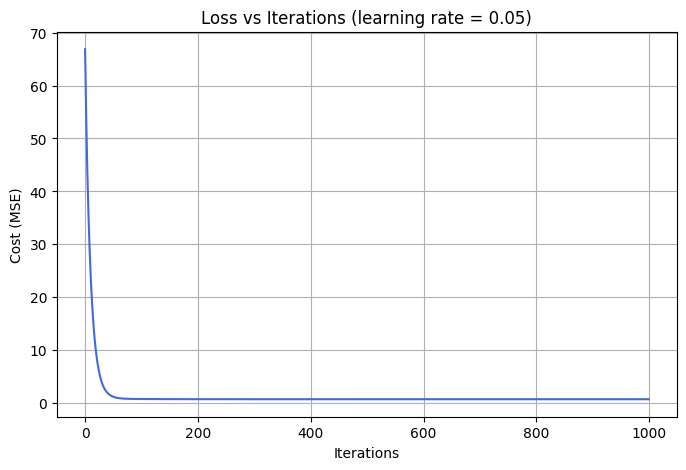

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history, color='royalblue')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title(f'Loss vs Iterations (learning rate = {learning_rate})')
plt.grid(True)
plt.show()

## EFFECT OF DIFFERENT LEARNING RATE ON CONVERGENCE

Iteration 0: Loss = 74.6455
Iteration 100: Loss = 60.2235
Iteration 200: Loss = 48.9808
Iteration 0: Loss = 73.1737
Iteration 100: Loss = 10.1827
Iteration 200: Loss = 2.0901
Iteration 0: Loss = 66.8592
Iteration 100: Loss = 0.7837
Iteration 200: Loss = 0.7549
Iteration 0: Loss = 59.4874
Iteration 100: Loss = 0.7547
Iteration 200: Loss = 0.7462


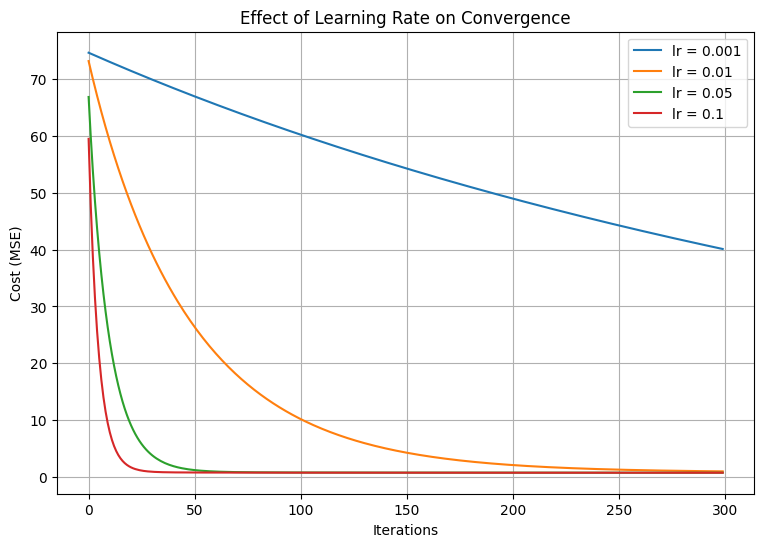

In [18]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
iterations_lr = 300

plt.figure(figsize=(9, 6))

for lr in learning_rates:
    _, cost_hist_lr = gradient_descent(
        X_train_bias, y_train_col, learning_rate=lr, iterations=iterations_lr
    )
    plt.plot(range(iterations_lr), cost_hist_lr, label=f"lr = {lr}")

plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.grid(True)
plt.show()

## MAKE PREDICTION IN THE TEST SET

In [15]:
y_pred_test = X_test_bias.dot(theta_final).flatten()
y_test_flat = y_test_col.flatten()

print("Sample predictions:", np.round(y_pred_test[:10], 2))
print("Sample actual values:", y_test_flat[:10])

Sample predictions: [18.4  11.83 18.56 10.81 11.74 16.52 17.69  9.21 10.99 10.53]
Sample actual values: [19. 12. 18. 11. 11. 17. 18.  8. 10. 11.]


## EVALUATE THE MODEL

In [16]:
mae = mean_absolute_error(y_test_flat, y_pred_test)
mse = mean_squared_error(y_test_flat, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_flat, y_pred_test)

print("==============================")
print("MODEL EVALUATION (Test Set)")
print("==============================")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R^2  : {r2:.4f}")

MODEL EVALUATION (Test Set)
MAE  : 0.7651
MSE  : 1.4761
RMSE : 1.2150
R^2  : 0.8486


## ACTUAL VS PREDICTED PLOT

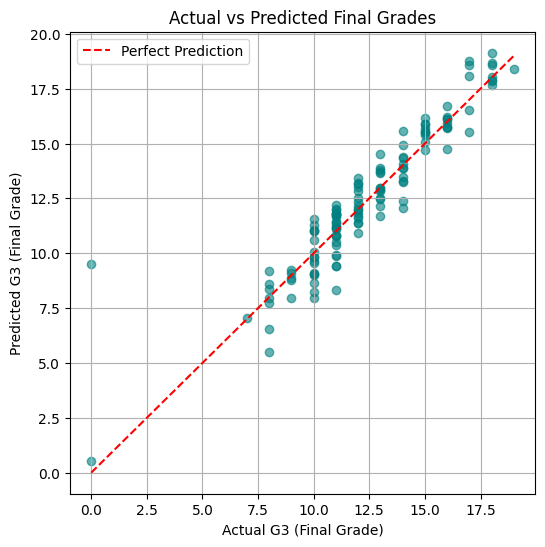

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_flat, y_pred_test, alpha=0.6, color='teal')
plt.plot([y_test_flat.min(), y_test_flat.max()],
         [y_test_flat.min(), y_test_flat.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual G3 (Final Grade)')
plt.ylabel('Predicted G3 (Final Grade)')
plt.title('Actual vs Predicted Final Grades')
plt.legend()
plt.grid(True)
plt.show()

## Interpretation of Results

- **Convergence behavior:** The loss vs. iterations plot shows the cost decreasing sharply during the first several dozen iterations before flattening out, indicating that Batch Gradient Descent converges smoothly for this dataset once features are standardized.
- **Effect of learning rate (Step 12):**
  - Very small learning rates (e.g. 0.001) reduce the cost too slowly and would need many more iterations to converge.
  - Moderate learning rates (e.g. 0.05–0.1) converge quickly and stably.
  - Very large learning rates (e.g. 0.5) can cause the cost to oscillate or diverge, since each update overshoots the minimum.
- **Prediction performance:** The MAE and RMSE values  indicate the typical error (in grade points) between predicted and actual final grades, while the R² score indicates how much of the variance in G3 is explained by the model — largely driven by the strong correlation between G1, G2 (period grades) and G3 (final grade).
- **Conclusion:** Gradient Descent successfully optimizes a Linear Regression model on real-world, mixed numeric/categorical data once the data is properly preprocessed (encoded and scaled), and the choice of learning rate has a major impact on how quickly and reliably the model converges.

## TYPES OF GD

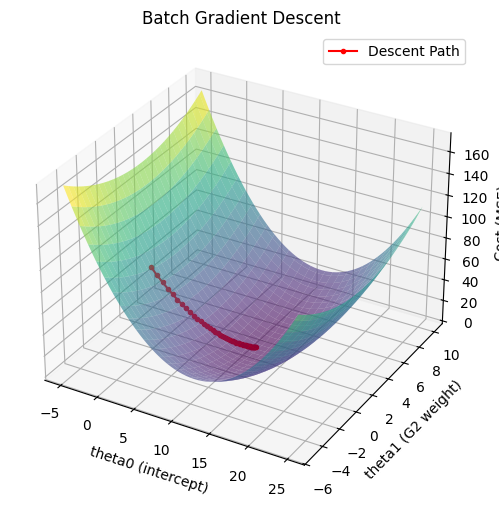

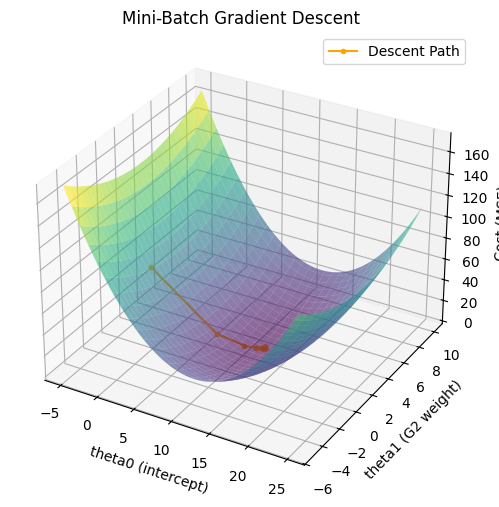

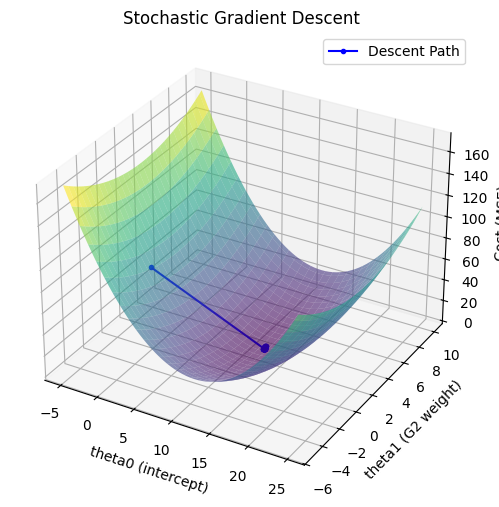

In [21]:
from mpl_toolkits.mplot3d import Axes3D

# --- Use a single feature (G2) so we have just 2 parameters to plot ---
X_single = X_train['G2'].values.reshape(-1, 1)
X_single_scaled = StandardScaler().fit_transform(X_single)

m_single = len(X_single_scaled)
X_single_bias = np.c_[np.ones((m_single, 1)), X_single_scaled]
y_single = y_train_col

# --- Track (theta0, theta1) history for each method ---
def batch_gd_history(X, y, learning_rate=0.05, epochs=50):
    theta = np.zeros((2, 1))
    history = [theta.flatten()]
    m = len(y)

    for epoch in range(epochs):
        predictions = X.dot(theta)
        gradients = (1 / m) * X.T.dot(predictions - y)
        theta = theta - learning_rate * gradients
        history.append(theta.flatten())

    return np.array(history)


def mini_batch_gd_history(X, y, learning_rate=0.05, epochs=50, batch_size=32):
    theta = np.zeros((2, 1))
    history = [theta.flatten()]
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled, y_shuffled = X[indices], y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            predictions = X_batch.dot(theta)
            gradients = (1 / len(X_batch)) * X_batch.T.dot(predictions - y_batch)
            theta = theta - learning_rate * gradients

        history.append(theta.flatten())

    return np.array(history)


def sgd_history(X, y, learning_rate=0.01, epochs=50):
    theta = np.zeros((2, 1))
    history = [theta.flatten()]
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled, y_shuffled = X[indices], y[indices]

        for i in range(m):
            xi = X_shuffled[i:i + 1]
            yi = y_shuffled[i:i + 1]
            predictions = xi.dot(theta)
            gradients = xi.T.dot(predictions - yi)
            theta = theta - learning_rate * gradients

        history.append(theta.flatten())

    return np.array(history)


hist_batch = batch_gd_history(X_single_bias, y_single)
hist_mini = mini_batch_gd_history(X_single_bias, y_single)
hist_sgd = sgd_history(X_single_bias, y_single)

# --- Build cost surface (same for all three) ---
theta0_vals = np.linspace(-5, 25, 60)
theta1_vals = np.linspace(-5, 10, 60)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_temp = np.array([[T0[i, j]], [T1[i, j]]])
        J_vals[i, j] = compute_cost(theta_temp, X_single_bias, y_single)

# --- Helper to plot one method ---
def plot_gd_path(history, title, color):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.6)

    costs = [compute_cost(t.reshape(-1, 1), X_single_bias, y_single) for t in history]
    ax.plot(history[:, 0], history[:, 1], costs,
            color=color, marker='o', markersize=3, label='Descent Path')

    ax.set_xlabel('theta0 (intercept)')
    ax.set_ylabel('theta1 (G2 weight)')
    ax.set_zlabel('Cost (MSE)')
    ax.set_title(title)
    plt.legend()
    plt.show()

# --- Three separate plots ---
plot_gd_path(hist_batch, 'Batch Gradient Descent', 'red')
plot_gd_path(hist_mini, 'Mini-Batch Gradient Descent', 'orange')
plot_gd_path(hist_sgd, 'Stochastic Gradient Descent', 'blue')